In [1]:
# https://www.kaggle.com/datasets/nunenuh/pytorch-challange-flower-dataset
# MNIST Dataset

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import idx2numpy

In [12]:
from math import ceil
import seaborn as sns
from sklearn.decomposition import PCA, FastICA, TruncatedSVD
from sklearn.manifold import MDS, TSNE
import umap

In [13]:
data_path = r"C:\Users\MedicineIT\Documents\ai\MNIST Dataset"

train_data = idx2numpy.convert_from_file(data_path + r"\train-images.idx3-ubyte")
train_labels = idx2numpy.convert_from_file(data_path + r"\train-labels.idx1-ubyte")
test_data = idx2numpy.convert_from_file(data_path + r"\t10k-images.idx3-ubyte")
test_labels = idx2numpy.convert_from_file(data_path + r"\t10k-labels.idx1-ubyte")

In [14]:
print(f'Train data {train_data.shape} \tTrain labels {train_labels.shape}')
print(f'Test data {test_data.shape} \tTest labels {test_labels.shape}')

Train data (60000, 28, 28) 	Train labels (60000,)
Test data (10000, 28, 28) 	Test labels (10000,)


In [15]:
print('Экземпляр обучающей выборки: ')
train_data[0]

Экземпляр обучающей выборки: 


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [16]:
print('Метка экземпляра обучающей выборки: ')
train_labels[0]

Метка экземпляра обучающей выборки: 


np.uint8(5)

In [17]:
lnames = {0: '0', 1: '1', 2: '2', 3: '3', 4: '4',
          5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}

rows:2, cols 5


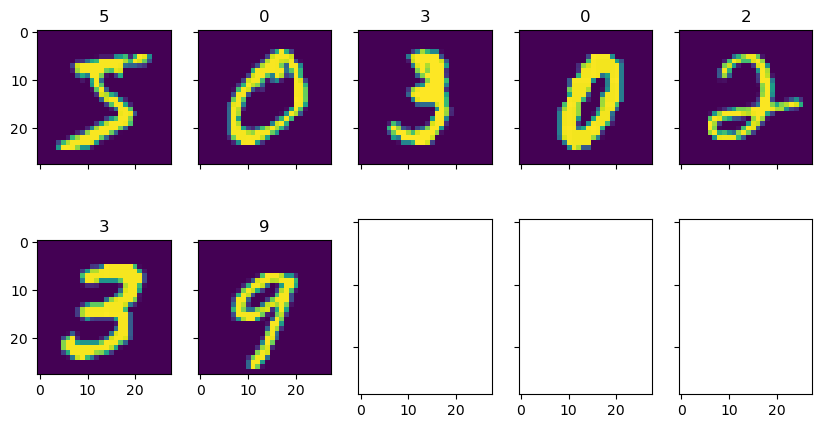

In [18]:
indexes = [0, 1, 10, 34, 16, 7, 45]
IMAGES_IN_ROW = 5
ROWS = ceil(len(indexes) / IMAGES_IN_ROW)
COLS = min(len(indexes), IMAGES_IN_ROW)
print(f"rows:{ROWS}, cols {COLS}")
fig, ax = plt.subplots(nrows=ROWS, ncols=COLS, figsize=(10,5), sharey=True, sharex=True)
for p, i in zip(enumerate(ax.flat), indexes):
  ind, axi = p
  img = train_data[i]
  axi.imshow(img)
  axi.set_title(lnames[train_labels[i]])
plt.show()

In [19]:
data_for_PCA = train_data.reshape([train_data.shape[0], train_data.shape[1] * train_data.shape[2]])
label_for_PCA = train_labels
print(data_for_PCA.shape)

(60000, 784)


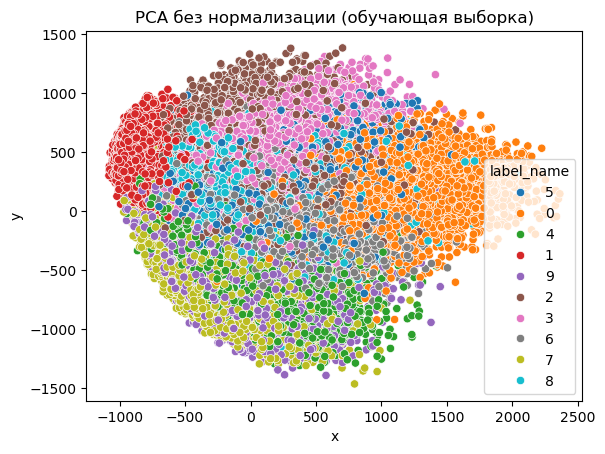

In [20]:
pca2D = PCA(n_components=2)
pca_2D = pca2D.fit_transform(data_for_PCA)
pca2D_df = pd.DataFrame(data = pca_2D, columns = ['x', 'y'])
pca2D_df['label'] = label_for_PCA
pca2D_df['label_name'] = pca2D_df['label'].apply(lambda x : lnames[x])
sns.scatterplot(x='x', y='y', hue='label_name', data=pca2D_df)
plt.title("PCA без нормализации (обучающая выборка)")
plt.show()

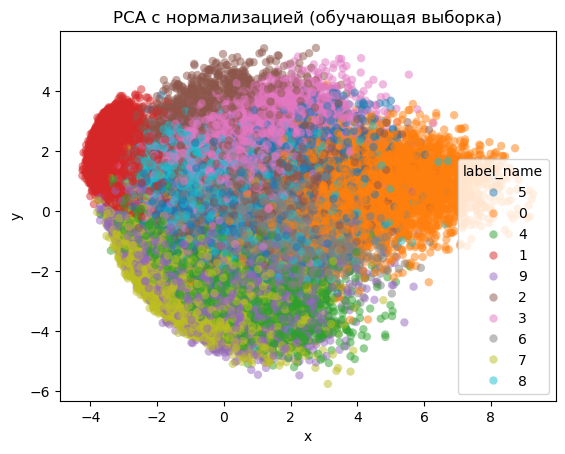

In [21]:
data_for_PCA = train_data.reshape([train_data.shape[0], train_data.shape[1] * train_data.shape[2]])
data_for_PCA = np.divide(data_for_PCA, 255)
Dmean = data_for_PCA.mean(axis=0)
data_for_PCA = data_for_PCA - Dmean

pca2D = PCA(n_components=2)
pca_2D = pca2D.fit_transform(data_for_PCA)
pca2D_df = pd.DataFrame(data = pca_2D, columns = ['x', 'y'])
pca2D_df['label'] = label_for_PCA
pca2D_df['label_name'] = pca2D_df['label'].apply(lambda x : lnames[x])
sns.scatterplot(x='x', y='y', hue='label_name', data=pca2D_df,
                alpha = 0.5, edgecolors='none')
plt.title("PCA с нормализацией (обучающая выборка)")
plt.show()

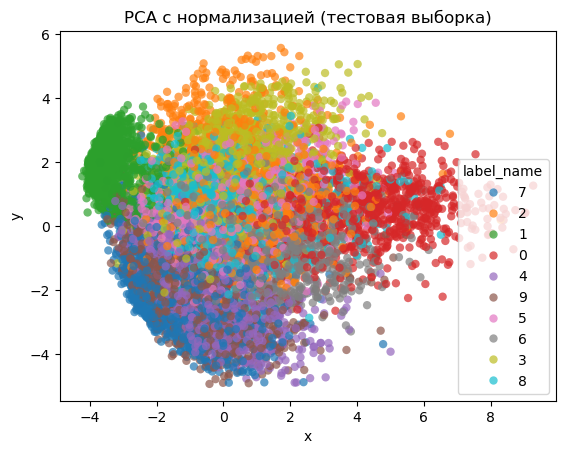

In [22]:
data_for_PCA = test_data.reshape([test_data.shape[0], test_data.shape[1] * test_data.shape[2]])
data_for_PCA = np.divide(data_for_PCA, 255)
Dmean = data_for_PCA.mean(axis=0)
data_for_PCA = data_for_PCA - Dmean
label_for_PCA = test_labels

pca2D = PCA(n_components=2)
pca_2D = pca2D.fit_transform(data_for_PCA)
pca2D_df = pd.DataFrame(data = pca_2D, columns = ['x', 'y'])
pca2D_df['label'] = label_for_PCA
pca2D_df['label_name'] = pca2D_df['label'].apply(lambda x : lnames[x])
sns.scatterplot(x='x', y='y', hue='label_name', data=pca2D_df,
                alpha = 0.7, edgecolors='none')
plt.title("PCA с нормализацией (тестовая выборка)")
plt.show()

In [23]:
N = 5000
X_sample = train_data[:N].reshape(N, -1)  # (5000, 784)
y_sample = train_labels[:N]

In [24]:
X_sample = np.divide(X_sample, 255)
X_sample = X_sample - X_sample.mean(axis=0)

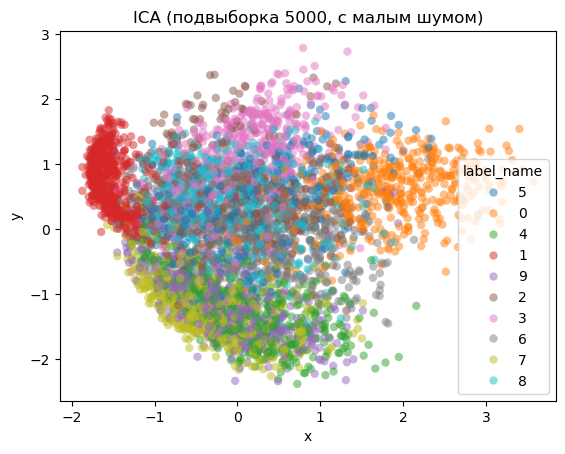

In [26]:
X_sample_noisy = X_sample + 1e-10 * np.random.randn(*X_sample.shape)
ica = FastICA(n_components=2, random_state=42, max_iter=500)
X_ica = ica.fit_transform(X_sample_noisy)
df_ica = pd.DataFrame(data=X_ica, columns=['x', 'y'])
df_ica['label'] = y_sample
df_ica['label_name'] = df_ica['label'].apply(lambda x: lnames[x])
sns.scatterplot(x='x', y='y', hue='label_name', data=df_ica, alpha=0.5, edgecolors='none')
plt.title("ICA (подвыборка 5000, с малым шумом)")
plt.show()

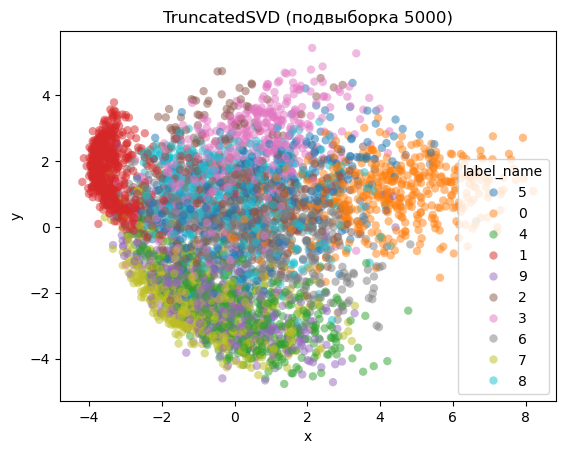

In [27]:
svd = TruncatedSVD(n_components=2, random_state=42)
X_svd = svd.fit_transform(X_sample)
df_svd = pd.DataFrame(data=X_svd, columns=['x', 'y'])
df_svd['label'] = y_sample
df_svd['label_name'] = df_svd['label'].apply(lambda x: lnames[x])
sns.scatterplot(x='x', y='y', hue='label_name', data=df_svd, alpha=0.5, edgecolors='none')
plt.title("TruncatedSVD (подвыборка 5000)")
plt.show()

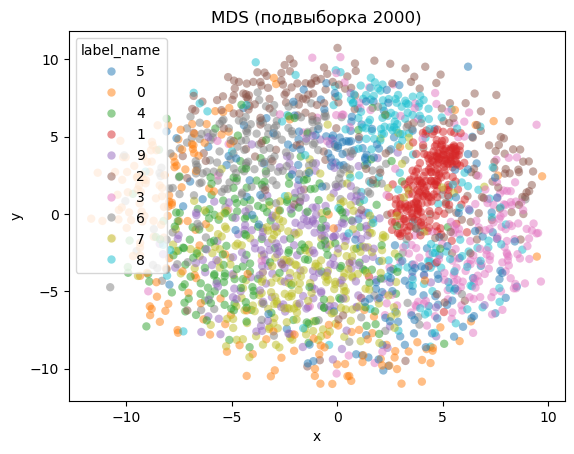

In [28]:
N_mds = 2000
X_mds = X_sample[:N_mds]
y_mds = y_sample[:N_mds]
mds = MDS(n_components=2, random_state=42, n_init=1, max_iter=300)
X_mds_res = mds.fit_transform(X_mds)
df_mds = pd.DataFrame(data=X_mds_res, columns=['x', 'y'])
df_mds['label'] = y_mds
df_mds['label_name'] = df_mds['label'].apply(lambda x: lnames[x])
sns.scatterplot(x='x', y='y', hue='label_name', data=df_mds, alpha=0.5, edgecolors='none')
plt.title("MDS (подвыборка 2000)")
plt.show()

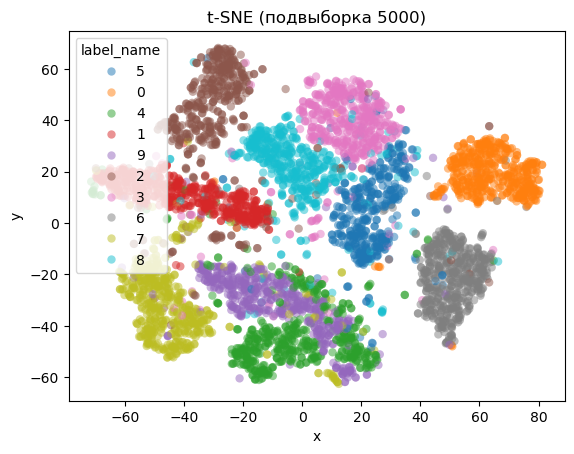

In [30]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_sample)  # 5000 точек
df_tsne = pd.DataFrame(data=X_tsne, columns=['x', 'y'])
df_tsne['label'] = y_sample
df_tsne['label_name'] = df_tsne['label'].apply(lambda x: lnames[x])
sns.scatterplot(x='x', y='y', hue='label_name', data=df_tsne, alpha=0.5, edgecolors='none')
plt.title("t-SNE (подвыборка 5000)")
plt.show()

C:\Users\MedicineIT\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


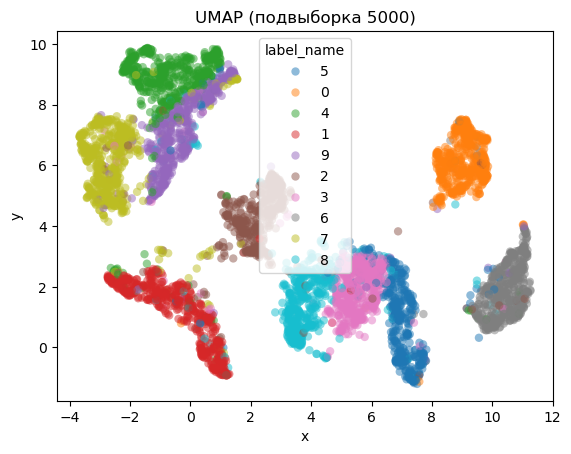

In [31]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_sample)
df_umap = pd.DataFrame(data=X_umap, columns=['x', 'y'])
df_umap['label'] = y_sample
df_umap['label_name'] = df_umap['label'].apply(lambda x: lnames[x])
sns.scatterplot(x='x', y='y', hue='label_name', data=df_umap, alpha=0.5, edgecolors='none')
plt.title("UMAP (подвыборка 5000)")
plt.show()